# Project 4: Data Classification With Respect to Urgency, Confusion and Sentiment
The objective of this project is to perform a complete descriptive analysis and required preprocessing on the dataset then classify with respect to urgency, confusion, and sentiment.

## Authors
### 1- Yousuf Islam Mohammad
### 2- Abdulrehman Hatem Hassan

## Phase 1: Data Loading & Initial Exploration
Importing libraries, loading the dataset, and performing an initial descriptive analysis of the raw data.

### Imports

In [232]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time


# Force a clean, white background for all plots (Perfect for PDF printing)
plt.style.use('default')
sns.set_theme(style="whitegrid", rc={"figure.facecolor": "white", "axes.facecolor": "white"})
from sklearn.model_selection import train_test_split
## Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

In [233]:
# Download the required NLTK data (only needs to be run once)
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [234]:
# Downloaded a small model for sentence embeddings
#%pip install sentence-transformers

### Loading Dataset

In [235]:
# Read and copy the data from the Excel file
df_moocs = pd.read_excel('moocs.xlsx', sheet_name='Sheet1')
df_moocs_copy = df_moocs.copy()

### Initial Data Exploration (EDA)

In [236]:
df_moocs_copy.head()

,Text,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),CourseType,forum_post_id,course_display_name,forum_uid,created_at,post_type,anonymous,anonymous_to_peers,up_count,comment_thread_id,reads
0,Interesting! How often we say those things to ...,1,0,0,6.5,2.0,1.5,Education,5225177f2c501f0a00000015,Education/EDUC115N/How_to_Learn_Math,30CADB93E6DE4711193D7BD05F2AE95C,2013-09-02 22:55:59,Comment,0.0,0.0,0.0,5221a8262cfae31200000001,41.0
1,"What is \Algebra as a Math Game\"" or are you j...",0,1,0,4.0,5.0,3.5,Education,5207d0e9935dfc0e0000005e,Education/EDUC115N/How_to_Learn_Math,37D8FAEE7D0B94B6CFC57D98FD3D0BA5,2013-08-11 17:59:05,Comment,0.0,0.0,0.0,520663839df35b0a00000043,55.0
2,I like the idea of my kids principal who says ...,1,0,0,5.5,3.0,2.5,Education,52052c82d01fec0a00000071,Education/EDUC115N/How_to_Learn_Math,CC11480215042B3EB6E5905EAB13B733,2013-08-09 17:53:06,Comment,0.0,0.0,0.0,51e59415e339d716000001a6,25.0
3,"From their responses, it seems the students re...",1,0,0,6.0,3.0,2.5,Education,5240a45e067ebf1200000008,Education/EDUC115N/How_to_Learn_Math,C717F838D10E8256D7C88B33C43623F1,2013-09-23 20:28:14,CommentThread,0.0,0.0,0.0,NaN,0.0
4,"The boys loved math, because \there is freedom...",1,0,0,7.0,2.0,3.0,Education,5212c5e2dd10251500000062,Education/EDUC115N/How_to_Learn_Math,F83887D68EA48964687C6441782CDD0E,2013-08-20 01:26:58,CommentThread,0.0,0.0,0.0,NaN,3.0


In [237]:
# General information about columns and null counts
print("--- Data Info ---")
df_moocs_copy.info()

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 29604 entries, 0 to 29603
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Text                 29603 non-null  object        
 1   Opinion(1/0)         29604 non-null  int64         
 2   Question(1/0)        29604 non-null  int64         
 3   Answer(1/0)          29604 non-null  int64         
 4   Sentiment(1-7)       29604 non-null  float64       
 5   Confusion(1-7)       29604 non-null  float64       
 6   Urgency(1-7)         29604 non-null  float64       
 7   CourseType           29602 non-null  str           
 8   forum_post_id        29590 non-null  object        
 9   course_display_name  29591 non-null  str           
 10  forum_uid            29585 non-null  object        
 11  created_at           29585 non-null  datetime64[us]
 12  post_type            29585 non-null  str           
 13  anonymous            295

In [238]:
# Statistical summary for numerical columns
print("\n--- Numerical Description ---")
display(df_moocs_copy.describe())


--- Numerical Description ---


,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),created_at,anonymous,anonymous_to_peers,up_count,reads
count,29604.000000,29604.000000,29604.000000,29604.000000,29604.000000,29604.000000,29585,29585.000000,29585.0,29585.000000,29585.000000
mean,0.556310,0.201290,0.204533,4.178658,3.910384,2.735171,2013-11-14 15:24:30.074396,0.017306,0.0,0.400980,410.736488
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2013-06-09 23:42:56,0.000000,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,4.000000,3.500000,1.500000,2013-08-06 21:12:30,0.000000,0.0,0.000000,16.000000
50%,1.000000,0.000000,0.000000,4.000000,4.000000,2.500000,2013-10-08 03:34:22,0.000000,0.0,0.000000,65.000000
75%,1.000000,0.000000,0.000000,4.500000,4.000000,3.500000,2014-02-06 05:46:26,0.000000,0.0,0.000000,191.000000
max,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,2014-08-08 08:00:36,1.000000,0.0,191.000000,9452.000000
std,0.496827,0.400971,0.403367,0.688520,0.606069,1.396435,NaN,0.130411,0.0,2.016614,1245.334869


In [239]:
# Statistical summary for categorical columns
print("\n--- Categorical Description ---")
display(df_moocs_copy.describe(include=['O']))# 'O' stands for object, which is typically used for categorical data in pandas


--- Categorical Description ---


,Text,CourseType,forum_post_id,course_display_name,forum_uid,post_type,comment_thread_id
count,29603,29602,29590,29591,29585,29585,17298
unique,29124,3,29587,11,11042,2,8271
top,Thanks!,Medicine,51d0fca0f7b9501600000002,Education/EDUC115N/How_to_Learn_Math,0FA78DE09E838CBB5DADAD13460046C7,Comment,52d3408ebcd7fc3aa100000c
freq,22,10001,2,9879,480,17298,276


In [240]:
# Inspect the shape of the DataFrame to understand how many rows and columns we have
df_moocs_copy.shape

(29604, 18)

In [ ]:
# Check for missing values
print(df_moocs_copy.isnull().sum())

Text                       1
Opinion(1/0)               0
Question(1/0)              0
Answer(1/0)                0
Sentiment(1-7)             0
Confusion(1-7)             0
Urgency(1-7)               0
CourseType                 2
forum_post_id             14
course_display_name       13
forum_uid                 19
created_at                19
post_type                 19
anonymous                 19
anonymous_to_peers        19
up_count                  19
comment_thread_id      12306
reads                     19
dtype: int64


## Phase 2: Data Cleaning
Handling missing values, dropping irrelevant columns (like IDs), and addressing duplicates.

In [241]:
# Drop ID columns  and others that are not needed for analysis
df_moocs_copy.drop(['forum_uid', 'forum_post_id', 'comment_thread_id', 'anonymous_to_peers'], axis=1, inplace=True)

print("New shape:", df_moocs_copy.shape)

New shape: (29604, 14)


In [242]:
#display rows with missing values to see if there is a pattern (there are 19 rows with missing values in most of the columns, which might need to be dropped)
df_moocs_copy[df_moocs_copy['post_type'].isna()]

,Text,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),CourseType,course_display_name,created_at,post_type,anonymous,up_count,reads
2801,1.\tCalculate Answer _x0007_\t- Ask students ...,1,0,0,4.0,2.5,3.0,NaN,Education/EDUC115N/How_to_Learn_Math,NaT,NaN,NaN,NaN,NaN
19098,Some more facts that might make you ask how mu...,1,0,0,4.0,4.0,3.0,Humanities,HumanitiesSciences/Econ-1/Summer2014,NaT,NaN,NaN,NaN,NaN
19589,I think your answer to Chp 3 Q6 can be improve...,0,0,1,4.0,3.5,2.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19590,ight)+hat{_x0008_eta}_1left(overline{x}-x_i\,0,0,0,4.0,4.0,1.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19591,> The bottom of Pg. 353 of the book makes the ...,0,1,0,4.0,5.0,5.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19592,You need to check your math; 10.6153 / 0.0055 ...,0,0,1,4.0,4.0,1.5,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19593,ight)$ term as $logleft( frac{0.5}{1-0.5} \,0,0,0,4.0,4.0,1.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19594,ight) = logleft( 1 \,0,0,0,4.0,4.0,1.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19595,I interpreted it as follows_x0007__x0007_$%_x0...,0,0,1,4.0,4.0,1.5,Humanities,NaN,NaT,NaN,NaN,NaN,NaN
19596,You have to be clear about what you mean when ...,0,0,1,4.0,4.0,2.0,Humanities,NaN,NaT,NaN,NaN,NaN,NaN


In [243]:
# Drop the rows where with missing values in 'post_type', 'CourseType', and 'Text' columns. 
df_moocs_copy.dropna(subset=['post_type', 'CourseType', 'Text'], inplace=True)

# Verify that the missing rows are gone
remaining_missing = df_moocs_copy[['post_type', 'CourseType', 'Text']].isna().sum()
print(f"Number of missing values in 'post_type', 'CourseType', and 'Text' after dropping: {remaining_missing}")

# Check the new shape of your dataframe to confirm missing rows have been removed
print("New shape:", df_moocs_copy.shape)

Number of missing values in 'post_type', 'CourseType', and 'Text' after dropping: post_type     0
CourseType    0
Text          0
dtype: int64
New shape: (29583, 14)


In [244]:
# 1. Convert the 'Text' column to string
df_moocs_copy['Text'] = df_moocs_copy['Text'].astype(str)

# 2. Count how many duplicates exist in the 'Text' column alone
text_duplicates_count = df_moocs_copy.duplicated(subset=['Text']).sum()
print(f"Number of duplicate texts: {text_duplicates_count}")

# 3. Extract all duplicate rows based on the 'Text' column
duplicate_texts = df_moocs_copy[df_moocs_copy.duplicated(subset=['Text'], keep=False)]

# 4. Sort and display the first 10 rows so you can see the matching texts together
print(df_moocs_copy['Text'].value_counts().head(10))

Number of duplicate texts: 478
Text
Thanks!                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        22
Thank you!                                                                                                                                                                                                                                                                                                                                                                                                                        

In [245]:
# More inspection of the duplicate texts
display(duplicate_texts.sort_values(by='Text'))

,Text,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),CourseType,course_display_name,created_at,post_type,anonymous,up_count,reads
25726,**THE SOLUTION**: I HAD THE SAME PROBLEM---GO ...,0,0,1,4.0,4.0,2.5,Medicine,Medicine/SciWrite/Fall2013,2013-10-25 21:28:10,Comment,0.0,0.0,115.0
25724,**THE SOLUTION**: I HAD THE SAME PROBLEM---GO ...,0,0,1,4.0,4.0,2.5,Medicine,Medicine/SciWrite/Fall2013,2013-10-25 21:27:46,Comment,0.0,0.0,115.0
25725,**THE SOLUTION**: I HAD THE SAME PROBLEM---GO ...,0,0,1,4.0,4.0,2.5,Medicine,Medicine/SciWrite/Fall2013,2013-10-25 21:27:59,Comment,0.0,0.0,115.0
23525,1,0,0,0,4.0,4.0,1.0,Medicine,Medicine/SciWrite/Fall2013,2013-09-27 07:31:39,Comment,0.0,0.0,107.0
11157,1,0,0,0,4.0,4.0,1.0,Humanities,HumanitiesScience/StatLearning/Winter2014,2014-01-22 20:22:53,Comment,0.0,0.0,1096.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20460,which program is used to analyze the data?,0,1,0,4.0,4.0,5.0,Medicine,Medicine/HRP258/Statistics_in_Medicine,2013-06-20 18:28:24,CommentThread,0.0,0.0,85.0
17763,yes,0,0,1,4.0,4.0,1.0,Humanities,HumanitiesScience/StatLearning/Winter2014,2014-04-04 18:34:41,Comment,0.0,0.0,939.0
21167,yes,0,0,1,4.0,4.0,1.0,Medicine,Medicine/HRP258/Statistics_in_Medicine,2013-07-04 02:46:04,Comment,0.0,0.0,266.0
13285,yes,0,0,0,4.0,4.0,2.0,Humanities,HumanitiesScience/StatLearning/Winter2014,2014-02-03 20:10:34,Comment,0.0,0.0,421.0


In [246]:
# Drop rows with duplicate text, keeping the first occurrence
df_moocs_copy.drop_duplicates(subset=['Text'], keep='first', inplace=True)

# Verify they are gone
remaining_duplicates = df_moocs_copy.duplicated(subset=['Text']).sum()
print(f"Number of duplicate texts remaining: {remaining_duplicates}")

# Check the new shape of your dataframe
print("New shape:", df_moocs_copy.shape)

Number of duplicate texts remaining: 0
New shape: (29105, 14)


## Phase 3: Feature Engineering
Extracting meaningful numerical variables from timestamps (Weekend vs. Weekday, Time of Day) and handling categorical variables to prevent data leakage.

### Visualization before feature engineering

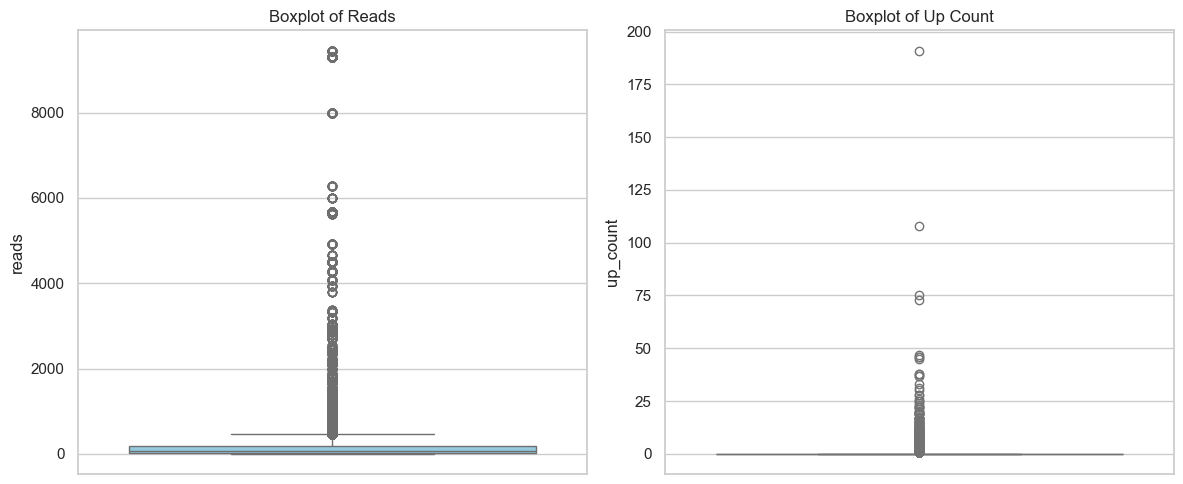

              reads      up_count
count  29105.000000  29105.000000
mean     413.910462      0.404879
std     1252.865524      2.031085
min        0.000000      0.000000
25%       16.000000      0.000000
50%       65.000000      0.000000
75%      193.000000      0.000000
max     9452.000000    191.000000


In [247]:
# Now let's visualize the distributions of 'reads' and 'up_count' to understand their ranges and how we will handle them in the next steps.
plt.figure(figsize=(12, 5))

# Boxplot for 'reads'
plt.subplot(1, 2, 1)
sns.boxplot(y=df_moocs_copy['reads'], color='skyblue')
plt.title('Boxplot of Reads')

# Boxplot for 'up_count'
plt.subplot(1, 2, 2)
sns.boxplot(y=df_moocs_copy['up_count'], color='lightgreen')
plt.title('Boxplot of Up Count')

plt.tight_layout()
plt.show()

print(df_moocs_copy[['reads', 'up_count']].describe())

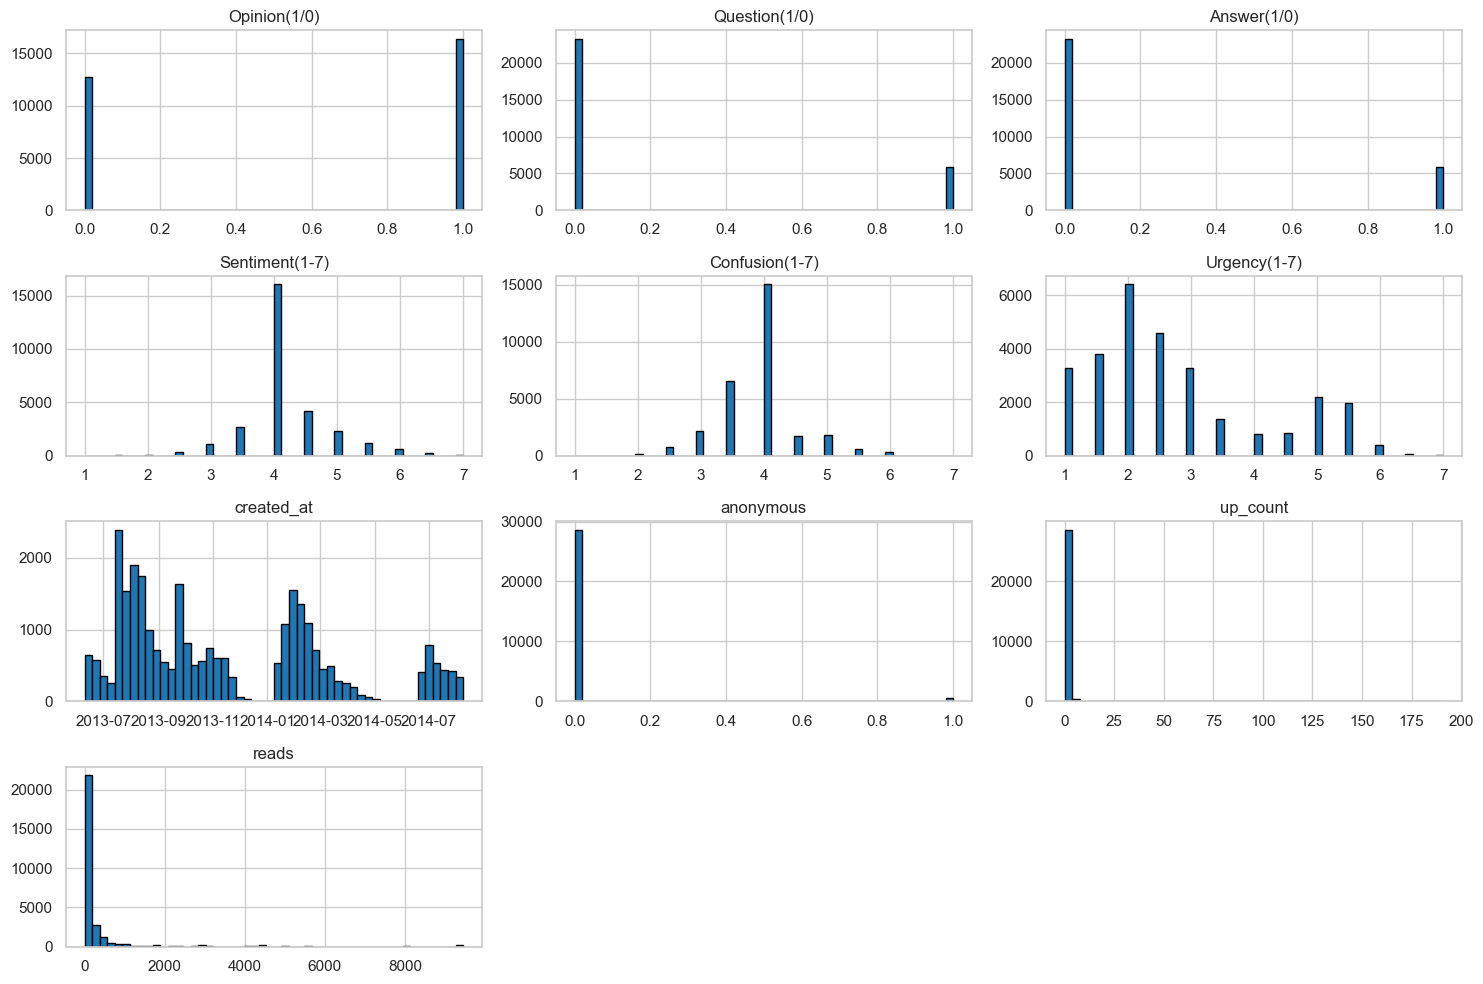

In [248]:
# Inspect the distribution of numeric features using histograms
df_moocs_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

In [249]:
# Convert 'created_at' to datetime format for any future time-based analysis
df_moocs_copy['created_at'] = pd.to_datetime(df_moocs_copy['created_at'])


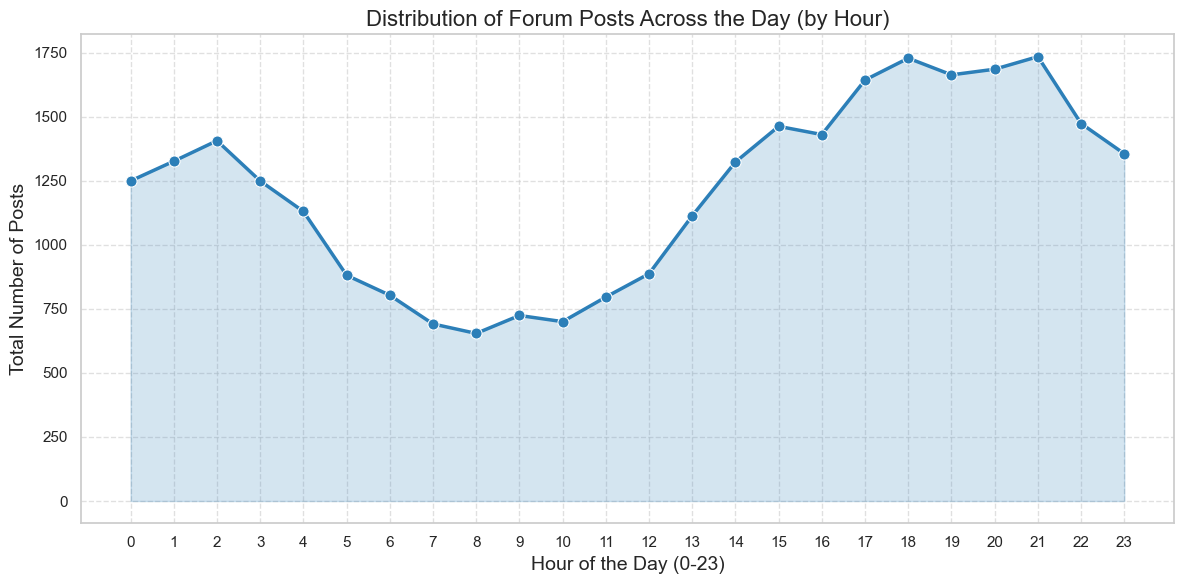

In [250]:
# We check the distribution of posts across the hours of the day to see if there are any patterns and how daytime affects posting behavior.
plt.figure(figsize=(12, 6))

# Extract the hour and count how many posts happened at each hour
hourly_counts = df_moocs_copy['created_at'].dt.hour.value_counts().sort_index()

# Create a line plot with markers
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', color='#2c7fb8', linewidth=2.5, markersize=8)
plt.fill_between(hourly_counts.index, hourly_counts.values, color='#2c7fb8', alpha=0.2)

plt.title('Distribution of Forum Posts Across the Day (by Hour)', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=14)
plt.ylabel('Total Number of Posts', fontsize=14)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

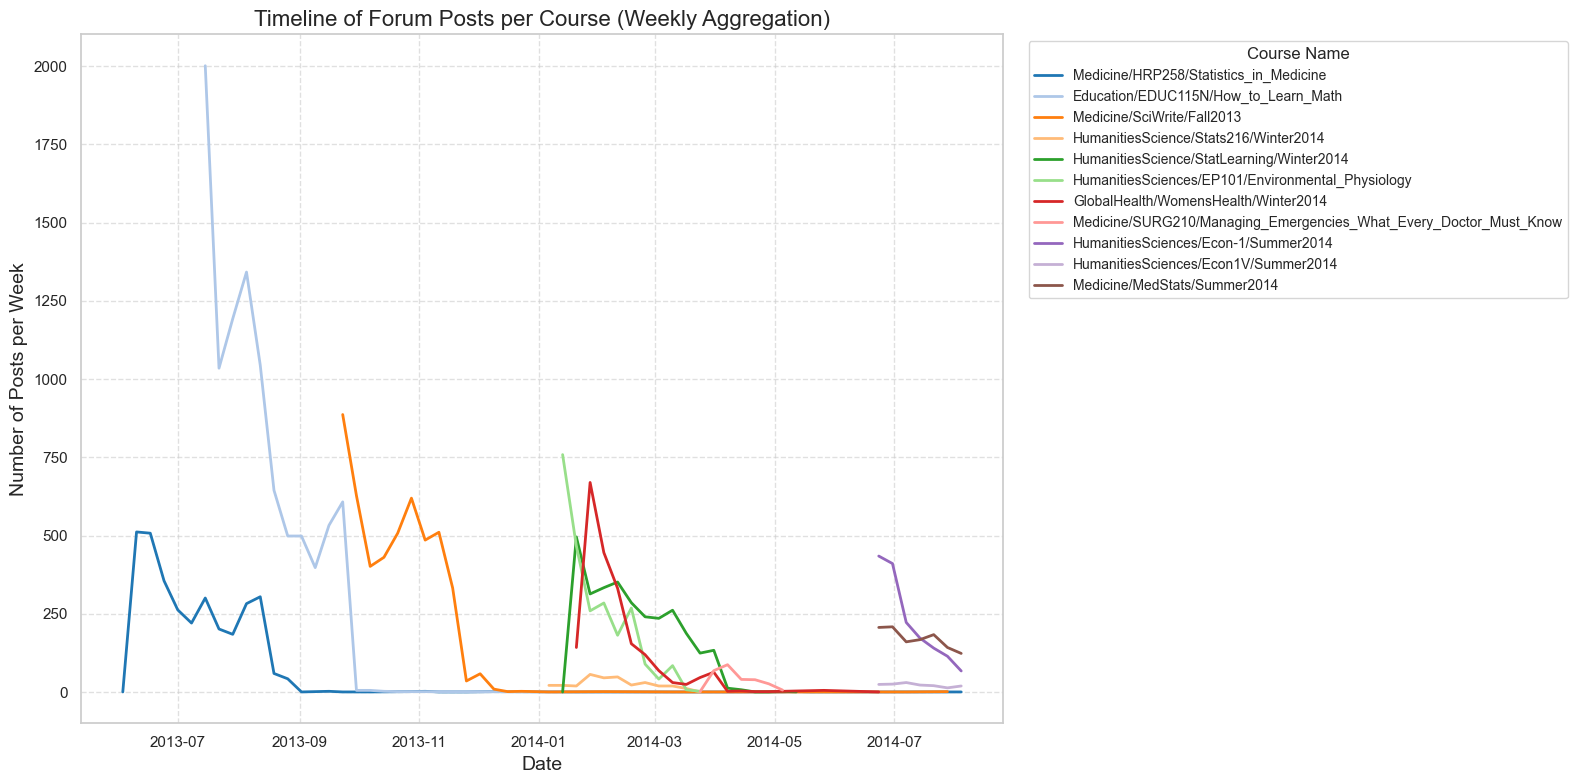

In [251]:
# Compare the posting activity over time for each course to see if there are any trends.

plt.figure(figsize=(16, 8))

# Create a temporary column that groups the exact timestamps into "Weeks"
df_moocs_copy['post_week'] = df_moocs_copy['created_at'].dt.to_period('W').dt.to_timestamp()

# Count the number of posts per week, per course
timeline_df = df_moocs_copy.groupby(['post_week', 'course_display_name']).size().reset_index(name='post_count')

# Plot the lines using hue to separate the courses by color
sns.lineplot(data=timeline_df, x='post_week', y='post_count', hue='course_display_name', palette='tab20', linewidth=2)

plt.title('Timeline of Forum Posts per Course (Weekly Aggregation)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts per Week', fontsize=14)

# Place the legend outside the plot
plt.legend(title='Course Name', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# Clean up the temporary 'post_week' column since we don't need it anymore
df_moocs_copy.drop('post_week', axis=1, inplace=True)


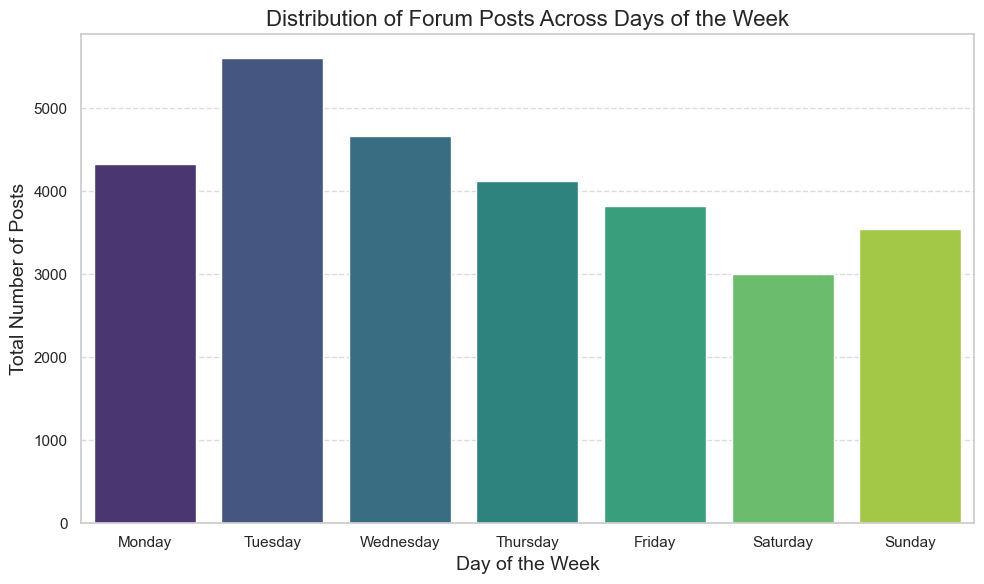

In [252]:
# Check the distribution of posts across the days of the week to see if there are any patterns and if certain days have more activity than others.

# Extract the day of the week (0 = Monday, 6 = Sunday)
df_moocs_copy['day_of_week'] = df_moocs_copy['created_at'].dt.dayofweek

# Map numbers to actual day names for a readable plot
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df_moocs_copy['day_name'] = df_moocs_copy['day_of_week'].map(day_mapping)

# Count the number of posts for each day and sort them logically (Mon -> Sun)
day_counts = df_moocs_copy['day_name'].value_counts().reindex(day_mapping.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')

plt.title('Distribution of Forum Posts Across Days of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Total Number of Posts', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Clean up the temporary columns used for plotting
df_moocs_copy.drop(['day_of_week', 'day_name'], axis=1, inplace=True)

In [253]:
# Check the distribution of the sentiment, confusion, and urgency scores to see if there is a correlation between them and invidual courses.

# Create the weekly timeline column
df_moocs_copy['post_week'] = pd.to_datetime(df_moocs_copy['created_at']).dt.to_period('W').dt.to_timestamp()

# Calculate both the MEAN of the metrics and the count of the posts
timeline_metrics = df_moocs_copy.groupby(['post_week', 'course_display_name']).agg(
    Sentiment=('Sentiment(1-7)', 'mean'),
    Confusion=('Confusion(1-7)', 'mean'),
    Urgency=('Urgency(1-7)', 'mean'),
    Post_Count=('Sentiment(1-7)', 'size') # This counts how many posts there were
).reset_index()

# ==========================================
# PLOT 1: Sentiment
# ==========================================
fig1 = px.line(timeline_metrics, x='post_week', y='Sentiment', color='course_display_name', 
               hover_data=['Post_Count'], title='Average Weekly Sentiment per Course',
               labels={'post_week': 'Date (Weekly)', 'Sentiment': 'Average Sentiment (1-7)'})
fig1.show()

# ==========================================
# PLOT 2: Confusion
# ==========================================
fig2 = px.line(timeline_metrics, x='post_week', y='Confusion', color='course_display_name', 
               hover_data=['Post_Count'], title='Average Weekly Confusion per Course',
               labels={'post_week': 'Date (Weekly)', 'Confusion': 'Average Confusion (1-7)'})
fig2.show()

# ==========================================
# PLOT 3: Urgency
# ==========================================
fig3 = px.line(timeline_metrics, x='post_week', y='Urgency', color='course_display_name', 
               hover_data=['Post_Count'], title='Average Weekly Urgency per Course',
               labels={'post_week': 'Date (Weekly)', 'Urgency': 'Average Urgency (1-7)'})
fig3.show()

# Clean up the temporary column
df_moocs_copy.drop('post_week', axis=1, inplace=True)

### Feature Engineering

In [254]:
# Use Pandas 'qcut' (Quantile-based discretization) to split 'reads' into 3 equal-sized buckets
df_moocs_copy['reads_binned'] = pd.qcut(df_moocs_copy['reads'], q=3, labels=['Low', 'Medium', 'High'])

# See how many rows fall into each category
print("\nDistribution of binned reads:")
print(df_moocs_copy['reads_binned'].value_counts())


Distribution of binned reads:
reads_binned
Low       9753
Medium    9702
High      9650
Name: count, dtype: int64


In [255]:
# Apply the mapping to the reads_binned column to create a new column 'reads_encoded' with the corresponding numeric values.
df_moocs_copy['reads_encoded'] = df_moocs_copy['reads_binned'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Check the results
print(df_moocs_copy[['reads', 'reads_binned', 'reads_encoded']].head())

# Drop not needed columns after encoding
df_moocs_copy.drop('reads_binned', axis=1, inplace=True)
df_moocs_copy.drop('reads', axis=1, inplace=True)

   reads reads_binned reads_encoded
0   41.0       Medium             1
1   55.0       Medium             1
2   25.0          Low             0
3    0.0          Low             0
4    3.0          Low             0


In [256]:
# Create a new binary column: 0 if up_count is 0, and 1 if up_count > 0 to indicate whether a post was upvoted or not.
df_moocs_copy['is_upvoted'] = (df_moocs_copy['up_count'] > 0).astype(int)

# Verify
print("Distribution of is_upvoted (0 = Not Upvoted, 1 = Upvoted):")
print(df_moocs_copy['is_upvoted'].value_counts())

# Now safely drop the original 'up_count' column
df_moocs_copy.drop('up_count', axis=1, inplace=True)

Distribution of is_upvoted (0 = Not Upvoted, 1 = Upvoted):
is_upvoted
0    23539
1     5566
Name: count, dtype: int64


In [257]:
# One-Hot Encode the categorical variables: 'CourseType', 'post_type', and 'course_display_name'
nominal_cols = ['CourseType', 'post_type', 'course_display_name']

df_moocs_copy = pd.get_dummies(df_moocs_copy, columns=nominal_cols, drop_first=True, dtype=int)

# View the new shape and columns to verify
print("New DataFrame shape:", df_moocs_copy.shape)
print("Columns:", df_moocs_copy.columns)

New DataFrame shape: (29105, 24)
Columns: Index(['Text', 'Opinion(1/0)', 'Question(1/0)', 'Answer(1/0)',
       'Sentiment(1-7)', 'Confusion(1-7)', 'Urgency(1-7)', 'created_at',
       'anonymous', 'reads_encoded', 'is_upvoted', 'CourseType_Humanities',
       'CourseType_Medicine', 'post_type_CommentThread',
       'course_display_name_GlobalHealth/WomensHealth/Winter2014',
       'course_display_name_HumanitiesScience/StatLearning/Winter2014',
       'course_display_name_HumanitiesScience/Stats216/Winter2014',
       'course_display_name_HumanitiesSciences/EP101/Environmental_Physiology',
       'course_display_name_HumanitiesSciences/Econ-1/Summer2014',
       'course_display_name_HumanitiesSciences/Econ1V/Summer2014',
       'course_display_name_Medicine/HRP258/Statistics_in_Medicine',
       'course_display_name_Medicine/MedStats/Summer2014',
       'course_display_name_Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know',
       'course_display_name_Medicine/SciWrit

In [258]:
# Now we will bin the 'Urgency(1-7)', 'Confusion(1-7)', and 'Sentiment(1-7)' columns into binary classes to simplify our analysis and modeling.
# Because we only need to predict whether a post is urgent/confused/positive or not.

# 1. Binning Urgency (0 = Not Urgent, 1 = Urgent)
# >= 4 is considered Urgent
df_moocs_copy['Urgency_Class'] = (df_moocs_copy['Urgency(1-7)'] >= 4).astype(int)

# 2. Binning Confusion (0 = Not Confused, 1 = Confused)
# >= 4 is considered Confused
df_moocs_copy['Confusion_Class'] = (df_moocs_copy['Confusion(1-7)'] >= 4).astype(int)

# 3. Binning Sentiment (0 = Negative/Neutral, 1 = Positive)
# >= 4 is considered a positive sentiment
df_moocs_copy['Sentiment_Class'] = (df_moocs_copy['Sentiment(1-7)'] >= 4).astype(int)


# Drop the original columns
columns_to_drop = ['Urgency(1-7)', 'Confusion(1-7)', 'Sentiment(1-7)']
df_moocs_copy.drop(columns_to_drop, axis=1, inplace=True)

In [259]:
# Create a binary 'Is_Weekend' feature (1 if Saturday or Sunday, 0 otherwise)
# We create this new feature to help our model pridict later.
# Based on the week days graph, we assumed that weekends are saturday and sunday.
df_moocs_copy['is_weekend'] = df_moocs_copy['created_at'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Check the balance of your new feature
print(df_moocs_copy['is_weekend'].value_counts())

is_weekend
0    22552
1     6553
Name: count, dtype: int64


In [260]:
# Make a new feature 'time_of_day' by binning the hours of the day into categories (Morning, Afternoon, Evening, Night) to capture any time-based patterns in posting behavior.

# Extract the raw hour (0 to 23)
df_moocs_copy['post_hour'] = df_moocs_copy['created_at'].dt.hour

# Bin the hours into logical 'Time of Day' categories
bins = [-1, 5, 11, 17, 23]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']
df_moocs_copy['time_of_day'] = pd.cut(df_moocs_copy['post_hour'], bins=bins, labels=labels)

# Drop the numerical 'post_hour'
df_moocs_copy.drop('post_hour', axis=1, inplace=True)

# One-Hot Encode the new 'time_of_day' column
df_moocs_copy = pd.get_dummies(df_moocs_copy, columns=['time_of_day'], drop_first=True, dtype=int)

# Drop the original datetime column
df_moocs_copy.drop('created_at', axis=1, inplace=True)


## Phase 4: Exploratory Data Analysis (EDA)
Visualizing the distribution of target variables, and temporal trends to identify patterns and class imbalances.

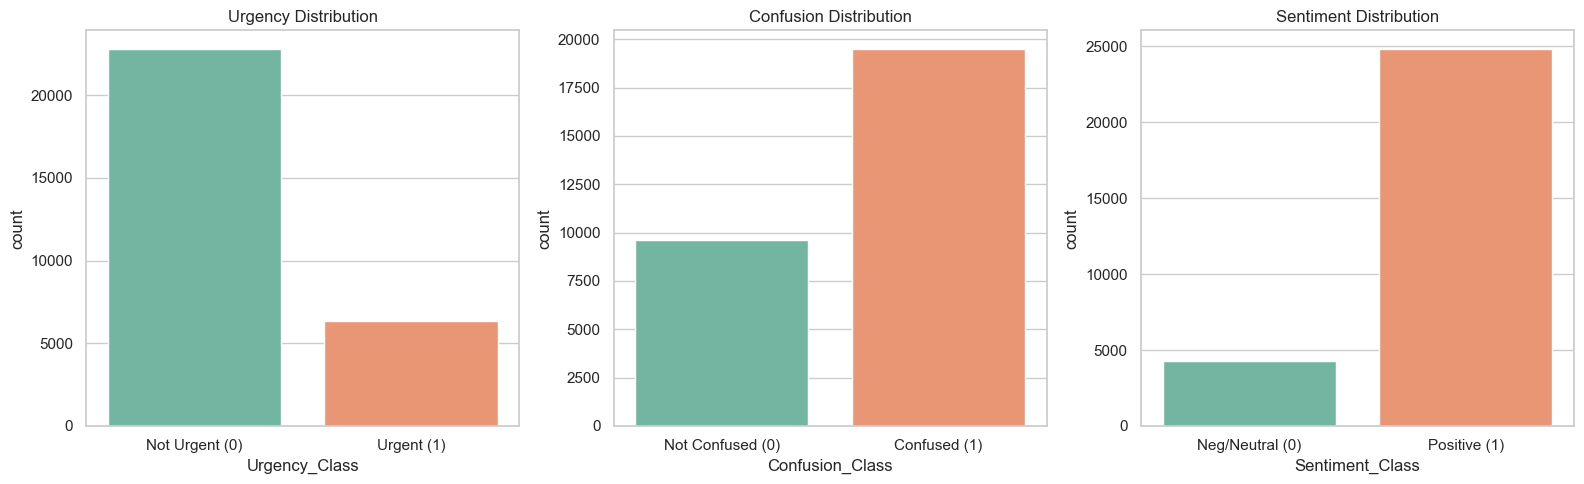

--- Urgency_Class ---
Counts:
Urgency_Class
0    22772
1     6333
Name: count, dtype: int64
Percentages:
Urgency_Class
0    78.24
1    21.76
Name: proportion, dtype: float64%

--- Confusion_Class ---
Counts:
Confusion_Class
1    19485
0     9620
Name: count, dtype: int64
Percentages:
Confusion_Class
1    66.95
0    33.05
Name: proportion, dtype: float64%

--- Sentiment_Class ---
Counts:
Sentiment_Class
1    24801
0     4304
Name: count, dtype: int64
Percentages:
Sentiment_Class
1    85.21
0    14.79
Name: proportion, dtype: float64%



In [261]:
# Verify the distributions to check for Data Imbalance

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot Urgency_Class
sns.countplot(data=df_moocs_copy, x='Urgency_Class', ax=axes[0], palette='Set2')
axes[0].set_title('Urgency Distribution')
axes[0].set_xticklabels(['Not Urgent (0)', 'Urgent (1)'])

# 2. Plot Confusion_Class
sns.countplot(data=df_moocs_copy, x='Confusion_Class', ax=axes[1], palette='Set2')
axes[1].set_title('Confusion Distribution')
axes[1].set_xticklabels(['Not Confused (0)', 'Confused (1)'])

# 3. Plot Sentiment_Class
sns.countplot(data=df_moocs_copy, x='Sentiment_Class', ax=axes[2], palette='Set2')
axes[2].set_title('Sentiment Distribution')
axes[2].set_xticklabels(['Neg/Neutral (0)', 'Positive (1)'])

plt.tight_layout()
plt.show()

# Print the exact numbers and percentages
target_cols = ['Urgency_Class', 'Confusion_Class', 'Sentiment_Class']

for col in target_cols:
    counts = df_moocs_copy[col].value_counts()
    percentages = df_moocs_copy[col].value_counts(normalize=True) * 100
    
    print(f"--- {col} ---")
    print(f"Counts:\n{counts}")
    print(f"Percentages:\n{percentages.round(2)}%\n")

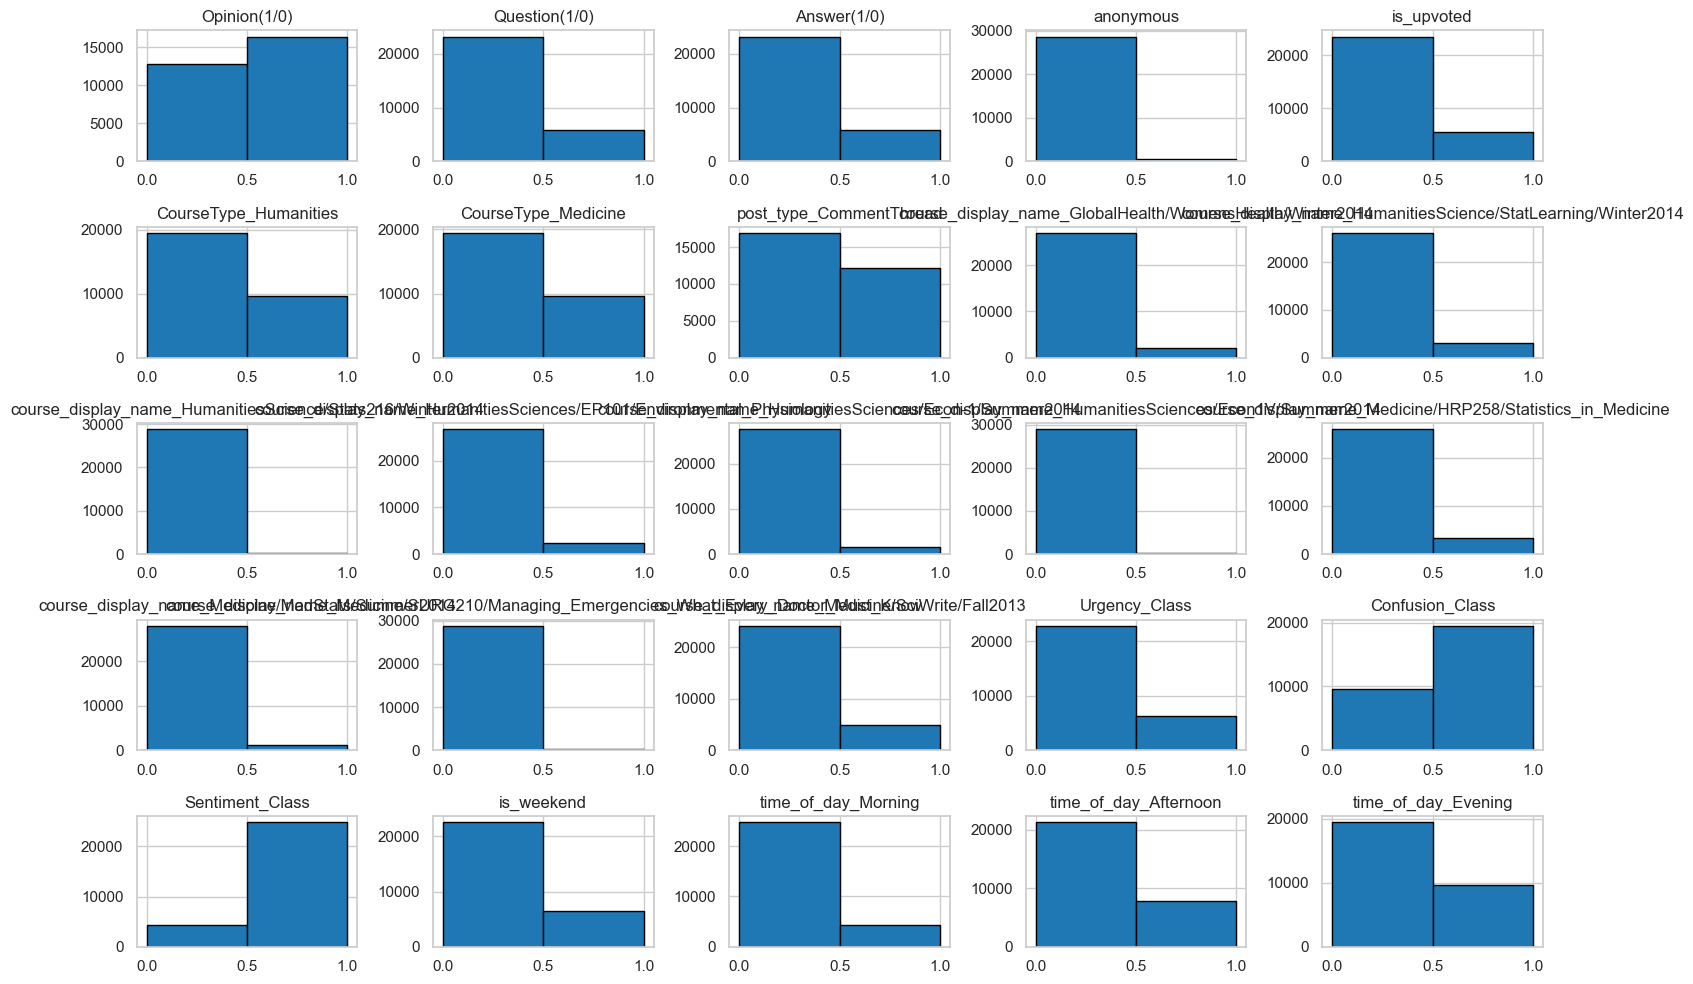

In [262]:
# Inspect the distribution of numeric features using histograms
df_moocs_copy.hist(bins=2, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

## Phase 5: NLP Text Preprocessing
Creating isolated pipelines to process the raw text into three distinct mathematical representations:
1. Term Frequency (TF)
2. Term Frequency-Inverse Document Frequency (TF-IDF)
3. Sentence Embeddings (all-MiniLM-L6-v2)

In [263]:
# Make copies of the dataframe for each type of text vectorization we will apply later.
# We will compare TF , TF-IDF, and Embeddings to see which one works best for our text data.
df_moocs_copy_tf = df_moocs_copy.copy()
df_moocs_copy_tfidf = df_moocs_copy.copy()
df_moocs_copy_embedding = df_moocs_copy.copy()

### Train-Test Split

In [264]:
# Define target columns
target_cols = ['Urgency_Class', 'Confusion_Class', 'Sentiment_Class']

# ==========================================
# 1. Split for TF Pipeline
# ==========================================
X_tf = df_moocs_copy_tf.drop(columns=target_cols)
y_tf = df_moocs_copy_tf[target_cols]

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tf, y_tf, test_size=0.20, random_state=42
)

# ==========================================
# 2. Split for TF-IDF Pipeline
# ==========================================
X_tfidf = df_moocs_copy_tfidf.drop(columns=target_cols)
y_tfidf = df_moocs_copy_tfidf[target_cols]

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y_tfidf, test_size=0.20, random_state=42
)

# ==========================================
# 3. Split for Embeddings Pipeline
# ==========================================
X_emb = df_moocs_copy_embedding.drop(columns=target_cols)
y_emb = df_moocs_copy_embedding[target_cols]

X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_emb, y_emb, test_size=0.20, random_state=42
)

# Verify 
print(f"TF Train shape: {X_train_tf.shape}, Test shape: {X_test_tf.shape}")
print(f"TF-IDF Train shape: {X_train_tfidf.shape}, Test shape: {X_test_tfidf.shape}")
print(f"Embedding Train shape: {X_train_emb.shape}, Test shape: {X_test_emb.shape}")

TF Train shape: (23284, 24), Test shape: (5821, 24)
TF-IDF Train shape: (23284, 24), Test shape: (5821, 24)
Embedding Train shape: (23284, 24), Test shape: (5821, 24)


### Cleaning Function for Tf and Tf-IDF

In [265]:
# Initialize the cleaning function and define English stop words to use to clean text data for tf and tf-idf pipelines.
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_for_tfidf(text):
    text = str(text).lower()
    
    # 1. Remove HTML/System tags completely
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 2. Remove hex values
    text = re.sub(r'_x[0-9a-f]+_', ' ', text)
    
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 4. Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    
    # 5. Remove standalone numbers
    text = re.sub(r'\d+', '', text)
    
    # 6. Split into words, remove stop words, and apply Lemmatization
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

# Test cleaning function on a sample messy comment from the dataset.
messy_comment = "I LOVE this question because it ties into so many avenues of systemic change! _x0007_Systemic change happens when there is total buy-in (I think) of a staff and unfortunately there will always be naysayers that will refuse to budge.  Some can be convince by \doing\" or teaching differently, watching the evidence and will buy in after seeing positive results.   SO, what would need to change?_x0007_1.  Follow through: most school systems \"buy\" a new system or curriculum for too short a time period to see results and so a time commitment would be necessary to be able to thoughtfully evaluate the change. _x0007_2. Language used by teachers (all staff that work with children).  How we communicate to students is at the foundation of this change in mindset.   If change would occur than all staff that worked with students would have to change their communication to students whether or not they agreed with the idea.   In other words there will be teachers who do have a fixed mindset, but would be required to offer praise contusive of the growth mindset."

print("--- Original ---")
print(messy_comment)
print("\n--- Cleaned ---")
print(clean_text_for_tfidf(messy_comment))

--- Original ---
I LOVE this question because it ties into so many avenues of systemic change! _x0007_Systemic change happens when there is total buy-in (I think) of a staff and unfortunately there will always be naysayers that will refuse to budge.  Some can be convince by \doing" or teaching differently, watching the evidence and will buy in after seeing positive results.   SO, what would need to change?_x0007_1.  Follow through: most school systems "buy" a new system or curriculum for too short a time period to see results and so a time commitment would be necessary to be able to thoughtfully evaluate the change. _x0007_2. Language used by teachers (all staff that work with children).  How we communicate to students is at the foundation of this change in mindset.   If change would occur than all staff that worked with students would have to change their communication to students whether or not they agreed with the idea.   In other words there will be teachers who do have a fixed min

### TF Pipeline

In [266]:
# ---------------------------------------------------------
# 1. CLEAN THE TEXT
# ---------------------------------------------------------
print("Cleaning TF training text...")
X_train_tf_clean = X_train_tf.copy()
X_train_tf_clean['Clean_Text'] = X_train_tf_clean['Text'].apply(clean_text_for_tfidf)

print("Cleaning TF testing text...")
X_test_tf_clean = X_test_tf.copy()
X_test_tf_clean['Clean_Text'] = X_test_tf_clean['Text'].apply(clean_text_for_tfidf)


# ---------------------------------------------------------
# 2. APPLY COUNT VECTORIZER (TERM FREQUENCY)
# ---------------------------------------------------------
print("Applying CountVectorizer...")
tf_vectorizer = CountVectorizer(max_features=5000)

# FIT on Train only, TRANSFORM on both Train and Test (No Data Leakage!)
X_train_tf_sparse = tf_vectorizer.fit_transform(X_train_tf_clean['Clean_Text'])
X_test_tf_sparse = tf_vectorizer.transform(X_test_tf_clean['Clean_Text'])


# ---------------------------------------------------------
# 3. APPLY TRUNCATED SVD (DIMENSIONALITY REDUCTION)
# ---------------------------------------------------------
# We make sure to apply SVD to reduce the number of feature for quicker modeling
print("Applying TruncatedSVD...")
# Compress the 5000 sparse columns into 100 dense conceptual columns
svd_tf = TruncatedSVD(n_components=100, random_state=42)

X_train_tf_svd = svd_tf.fit_transform(X_train_tf_sparse)
X_test_tf_svd = svd_tf.transform(X_test_tf_sparse)

# Convert the SVD numpy arrays back into Pandas DataFrames
df_train_tf_svd = pd.DataFrame(X_train_tf_svd, index=X_train_tf_clean.index)
df_test_tf_svd = pd.DataFrame(X_test_tf_svd, index=X_test_tf_clean.index)

# Give the new columns generic names (e.g., tf_svd_0, tf_svd_1)
df_train_tf_svd.columns = [f'tf_svd_{i}' for i in range(100)]
df_test_tf_svd.columns = [f'tf_svd_{i}' for i in range(100)]


# ---------------------------------------------------------
# 4. MERGE BACK WITH NUMERICAL FEATURES
# ---------------------------------------------------------
print("Merging features...")
# Drop the raw text strings because models can't read them
X_train_num_tf = X_train_tf_clean.drop(['Text', 'Clean_Text'], axis=1)
X_test_num_tf = X_test_tf_clean.drop(['Text', 'Clean_Text'], axis=1)

# Concatenate the numeric columns with the 100 new text columns
X_train_final_tf = pd.concat([X_train_num_tf, df_train_tf_svd], axis=1)
X_test_final_tf = pd.concat([X_test_num_tf, df_test_tf_svd], axis=1)

print("\n--- TF Pipeline Complete! ---")
print(f"Final TF Training Data Shape: {X_train_final_tf.shape}")
print(f"Final TF Testing Data Shape: {X_test_final_tf.shape}")

Cleaning TF training text...
Cleaning TF testing text...
Applying CountVectorizer...
Applying TruncatedSVD...
Merging features...

--- TF Pipeline Complete! ---
Final TF Training Data Shape: (23284, 123)
Final TF Testing Data Shape: (5821, 123)


### TF-IDF Pipeline

In [267]:
# ---------------------------------------------------------
# 1. CLEAN THE TEXT
# ---------------------------------------------------------
print("Cleaning TF-IDF training text...")
X_train_tfidf_clean = X_train_tfidf.copy()
X_train_tfidf_clean['Clean_Text'] = X_train_tfidf_clean['Text'].apply(clean_text_for_tfidf)

print("Cleaning TF-IDF testing text...")
X_test_tfidf_clean = X_test_tfidf.copy()
X_test_tfidf_clean['Clean_Text'] = X_test_tfidf_clean['Text'].apply(clean_text_for_tfidf)


# ---------------------------------------------------------
# 2. APPLY TF-IDF VECTORIZER
# ---------------------------------------------------------
print("Applying TfidfVectorizer...")
# Restrict to the top 5000 most meaningful words
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# FIT on Train only, TRANSFORM on both Train and Test
X_train_tfidf_sparse = tfidf_vectorizer.fit_transform(X_train_tfidf_clean['Clean_Text'])
X_test_tfidf_sparse = tfidf_vectorizer.transform(X_test_tfidf_clean['Clean_Text'])


# ---------------------------------------------------------
# 3. APPLY TRUNCATED SVD (DIMENSIONALITY REDUCTION)
# ---------------------------------------------------------
# We make sure to apply SVD to reduce the number of feature for quicker modeling
print("Applying TruncatedSVD...")
# Compress the 5000 sparse columns into 100 dense conceptual columns
svd_tfidf = TruncatedSVD(n_components=100, random_state=42)

X_train_tfidf_svd = svd_tfidf.fit_transform(X_train_tfidf_sparse)
X_test_tfidf_svd = svd_tfidf.transform(X_test_tfidf_sparse)

# Convert the SVD numpy arrays back into Pandas DataFrames
df_train_tfidf_svd = pd.DataFrame(X_train_tfidf_svd, index=X_train_tfidf_clean.index)
df_test_tfidf_svd = pd.DataFrame(X_test_tfidf_svd, index=X_test_tfidf_clean.index)

# Give the new columns generic names (e.g., tfidf_svd_0, tfidf_svd_1)
df_train_tfidf_svd.columns = [f'tfidf_svd_{i}' for i in range(100)]
df_test_tfidf_svd.columns = [f'tfidf_svd_{i}' for i in range(100)]


# ---------------------------------------------------------
# 4. MERGE BACK WITH NUMERICAL FEATURES
# ---------------------------------------------------------
print("Merging features...")
# Drop the raw text strings
X_train_num_tfidf = X_train_tfidf_clean.drop(['Text', 'Clean_Text'], axis=1)
X_test_num_tfidf = X_test_tfidf_clean.drop(['Text', 'Clean_Text'], axis=1)

# Concatenate the numeric columns with the 100 new text columns
X_train_final_tfidf = pd.concat([X_train_num_tfidf, df_train_tfidf_svd], axis=1)
X_test_final_tfidf = pd.concat([X_test_num_tfidf, df_test_tfidf_svd], axis=1)

print("\n--- TF-IDF Pipeline Complete! ---")
print(f"Final TF-IDF Training Data Shape: {X_train_final_tfidf.shape}")
print(f"Final TF-IDF Testing Data Shape: {X_test_final_tfidf.shape}")

Cleaning TF-IDF training text...
Cleaning TF-IDF testing text...
Applying TfidfVectorizer...
Applying TruncatedSVD...
Merging features...

--- TF-IDF Pipeline Complete! ---
Final TF-IDF Training Data Shape: (23284, 123)
Final TF-IDF Testing Data Shape: (5821, 123)


### Embeddings Pipeline and its Cleaning Function

In [268]:
# We apply only light cleaning since the embedding model needs full context to generate meaningful vectors.

def clean_text_for_embedding(text):
    text = str(text)
    # Remove HTML/System tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove hex artifacts
    text = re.sub(r'_x[0-9a-f]+_', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    return " ".join(text.split())

In [269]:
# ---------------------------------------------------------
# 1. CLEAN THE TEXT
# ---------------------------------------------------------

print("Cleaning Embedding training text...")
X_train_emb_clean = X_train_emb.copy()
X_train_emb_clean['Clean_Text'] = X_train_emb_clean['Text'].apply(clean_text_for_embedding)

print("Cleaning Embedding testing text...")
X_test_emb_clean = X_test_emb.copy()
X_test_emb_clean['Clean_Text'] = X_test_emb_clean['Text'].apply(clean_text_for_embedding)


# ---------------------------------------------------------
# 2. GENERATE SENTENCE EMBEDDINGS
# ---------------------------------------------------------
print("\nLoading Sentence Transformer Model (all-MiniLM-L6-v2)...")
# This model will download automatically the first time you run it
# We picked a small model to keep the embedding generation time reasonable.
# The 'all-MiniLM-L6-v2' model generates 384-dimensional dense vectors.
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding Training Text (This will take a few minutes!)...")
train_embeddings = model.encode(X_train_emb_clean['Clean_Text'].tolist(), show_progress_bar=True)

print("Encoding Testing Text...")
test_embeddings = model.encode(X_test_emb_clean['Clean_Text'].tolist(), show_progress_bar=True)


df_train_emb = pd.DataFrame(train_embeddings, index=X_train_emb_clean.index)
df_train_emb.columns = [f'emb_{i}' for i in range(384)]

df_test_emb = pd.DataFrame(test_embeddings, index=X_test_emb_clean.index)
df_test_emb.columns = [f'emb_{i}' for i in range(384)]


# ---------------------------------------------------------
# 3. MERGE BACK WITH NUMERICAL FEATURES
# ---------------------------------------------------------
print("\nMerging features...")
# Drop the raw text
X_train_num_emb = X_train_emb_clean.drop(['Text', 'Clean_Text'], axis=1)
X_test_num_emb = X_test_emb_clean.drop(['Text', 'Clean_Text'], axis=1)

# Concatenate numeric features with our 384 new deep learning columns
X_train_final_emb = pd.concat([X_train_num_emb, df_train_emb], axis=1)
X_test_final_emb = pd.concat([X_test_num_emb, df_test_emb], axis=1)

print("\n--- Embedding Pipeline Complete! ---")
print(f"Final Embedding Training Data Shape: {X_train_final_emb.shape}")

Cleaning Embedding training text...
Cleaning Embedding testing text...

Loading Sentence Transformer Model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4423.69it/s]


Encoding Training Text (This will take a few minutes!)...


Batches: 100%|██████████| 728/728 [04:55<00:00,  2.46it/s]


Encoding Testing Text...


Batches: 100%|██████████| 182/182 [01:04<00:00,  2.81it/s]



Merging features...

--- Embedding Pipeline Complete! ---
Final Embedding Training Data Shape: (23284, 407)


## Phase 6: Baseline Model Evaluation
Testing Logistic Regression across all three text representations (TF, TF-IDF, Embeddings) to determine the optimal text processing strategy based on F1-Score.

In [270]:
# We use Simple Logistic Regression as our baseline model to evaluate the performance of each text representation method (TF, TF-IDF, and Embeddings) across
#  all 3 target variables (Urgency, Confusion, Sentiment).

# 1. Define the 3 targets
targets = ['Urgency_Class', 'Confusion_Class', 'Sentiment_Class']

# 2. Package the 3 datasets into a dictionary
datasets = {
    '1. TF': (X_train_final_tf, X_test_final_tf),
    '2. TF-IDF': (X_train_final_tfidf, X_test_final_tfidf),
    '3. Embeddings': (X_train_final_emb, X_test_final_emb)
}

# 3. Define the Baseline Model
# class_weight='balanced' is CRITICAL here to handle the class imbanances we observed earlier.
baseline_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

baseline_results = []

print("Starting Baseline Evaluation (Logistic Regression) for all 3 Targets...\n")

# 4. Nested Loop: Targets -> Datasets
for target in targets:
    # Since we used random_state=42 for all splits, y_tf, y_tfidf, and y_emb are exactly the same.
    # We can safely just pull the target column from y_train_tf and y_test_tf
    y_train = y_train_tf[target]
    y_test = y_test_tf[target]
    
    for dataset_name, (X_train, X_test) in datasets.items():
        # Fit the model
        baseline_model.fit(X_train, y_train)
        
        # Predict
        y_pred = baseline_model.predict(X_test)
        
        # Calculate Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted') 
        
        # Save results
        baseline_results.append({
            'Target Variable': target,
            'Text Representation': dataset_name,
            'Accuracy': round(acc * 100, 2),
            'F1-Score': round(f1 * 100, 2)
        })

# 5. Build and display the comparison matrices
df_baseline = pd.DataFrame(baseline_results)

# Pivot tables to make them look like professional report matrices
pivot_acc = df_baseline.pivot(index='Target Variable', columns='Text Representation', values='Accuracy')
pivot_f1 = df_baseline.pivot(index='Target Variable', columns='Text Representation', values='F1-Score')

print("BASELINE ACCURACY (%)")
print("-" * 40)
print(pivot_acc)
print("\n\nBASELINE F1-SCORE (%)")
print("-" * 40)
print(pivot_f1)

Starting Baseline Evaluation (Logistic Regression) for all 3 Targets...

BASELINE ACCURACY (%)
----------------------------------------
Text Representation  1. TF  2. TF-IDF  3. Embeddings
Target Variable                                     
Confusion_Class      82.13      82.56          82.80
Sentiment_Class      74.51      76.09          79.11
Urgency_Class        88.89      89.18          89.35


BASELINE F1-SCORE (%)
----------------------------------------
Text Representation  1. TF  2. TF-IDF  3. Embeddings
Target Variable                                     
Confusion_Class      82.49      82.93          83.18
Sentiment_Class      77.77      79.09          81.56
Urgency_Class        89.19      89.48          89.69


## Phase 7: Final Model Comparison
Training the 5 required algorithms (Naïve Bayes, SVM, Random Forest, AdaBoost, Logistic Regression) on the winning text representation (Embeddings) to identify the best classifiers for each target variable.

In [271]:
# Compare all 5 models on the winning text representation (which is the Embeddings dataset) to pick the best two for grid search tuning in the next step.

# 1. The 3 Targets
targets = ['Urgency_Class', 'Confusion_Class', 'Sentiment_Class']

# 2. The 5 Required Models (Using class_weight='balanced' to handle the class imbalance)
models = {
    '1. Naïve Bayes': GaussianNB(),
    '2. SVM': SVC(class_weight='balanced', random_state=42),
    '3. Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    '4. AdaBoost': AdaBoostClassifier(random_state=42),
    '5. Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
}

final_results = []

print("Training 5 Classifiers on the Winning Embeddings Universe...\n")

# 3. The Training Loop
for target in targets:
    print(f"=== Predicting: {target} ===")
    
    # Extract the specific target column
    y_train = y_train_emb[target]
    y_test = y_test_emb[target]
    
    for model_name, model in models.items():
        print(f" -> Training {model_name}...")
        
        # Fit the model on the Embeddings dataset
        model.fit(X_train_final_emb, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_final_emb)
        
        # Calculate Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted') 
        
        # Save results
        final_results.append({
            'Target': target,
            'Model': model_name,
            'Accuracy (%)': round(acc * 100, 2),
            'F1-Score (%)': round(f1 * 100, 2)
        })
    print("\n")

# 4. Build and Display the Final Matrices
df_final = pd.DataFrame(final_results)

pivot_acc = df_final.pivot(index='Model', columns='Target', values='Accuracy (%)')
pivot_f1 = df_final.pivot(index='Model', columns='Target', values='F1-Score (%)')

print("FINAL ACCURACY LEADERBOARD (EMBEDDINGS)")
print("-" * 50)
print(pivot_acc)
print("\n\nFINAL F1-SCORE LEADERBOARD (EMBEDDINGS)")
print("-" * 50)
print(pivot_f1)

Training 5 Classifiers on the Winning Embeddings Universe...

=== Predicting: Urgency_Class ===
 -> Training 1. Naïve Bayes...
 -> Training 2. SVM...
 -> Training 3. Random Forest...
 -> Training 4. AdaBoost...
 -> Training 5. Logistic Regression...


=== Predicting: Confusion_Class ===
 -> Training 1. Naïve Bayes...
 -> Training 2. SVM...
 -> Training 3. Random Forest...
 -> Training 4. AdaBoost...
 -> Training 5. Logistic Regression...


=== Predicting: Sentiment_Class ===
 -> Training 1. Naïve Bayes...
 -> Training 2. SVM...
 -> Training 3. Random Forest...
 -> Training 4. AdaBoost...
 -> Training 5. Logistic Regression...


FINAL ACCURACY LEADERBOARD (EMBEDDINGS)
--------------------------------------------------
Target                  Confusion_Class  Sentiment_Class  Urgency_Class
Model                                                                  
1. Naïve Bayes                    80.23            73.63          76.69
2. SVM                            83.75            82.37 

## Phase 8: Hyperparameter Optimization (GridSearch)
Applying GridSearchCV to the top two performing algorithms for each target variable to optimize their mathematical parameters and maximize the final F1-Score.

### Urgency Class

In [272]:
# Apply Grid Search Hyperparameter Tuning to the top 2 models for the Urgency Class target variable 

print("Starting Hyperparameter Tuning for URGENCY_CLASS \n")
start_time = time.time()

# 1. Define the Targets for Urgency
y_train_u = y_train_emb['Urgency_Class']
y_test_u = y_test_emb['Urgency_Class']

# ==========================================
# MODEL 1: ADABOOST
# ==========================================
print("Tuning AdaBoost (This may take a few minutes)...")
ada_base = AdaBoostClassifier(random_state=42)
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=ada_base, 
    param_grid=ada_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_ada.fit(X_train_final_emb, y_train_u)
best_ada = grid_ada.best_estimator_

# Predict and Evaluate AdaBoost
y_pred_ada = best_ada.predict(X_test_final_emb)
acc_ada = accuracy_score(y_test_u, y_pred_ada)
prec_ada = precision_score(y_test_u, y_pred_ada, average='weighted', zero_division=0)
rec_ada = recall_score(y_test_u, y_pred_ada, average='weighted', zero_division=0)
f1_ada = f1_score(y_test_u, y_pred_ada, average='weighted')

# ==========================================
# MODEL 2: SVM
# ==========================================
print("Tuning SVM (This may take a few minutes)...")
svm_base = SVC(class_weight='balanced', random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    estimator=svm_base, 
    param_grid=svm_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_svm.fit(X_train_final_emb, y_train_u)
best_svm = grid_svm.best_estimator_

# Predict and Evaluate SVM
y_pred_svm = best_svm.predict(X_test_final_emb)
acc_svm = accuracy_score(y_test_u, y_pred_svm)
prec_svm = precision_score(y_test_u, y_pred_svm, average='weighted', zero_division=0)
rec_svm = recall_score(y_test_u, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test_u, y_pred_svm, average='weighted')

end_time = time.time()

# ==========================================
# FINAL REPORT OUTPUT
# ==========================================
print("\n" + "="*50)
print("URGENCY_CLASS TUNING COMPLETE")
print("="*50)
print(f"Total Time Taken: {round((end_time - start_time)/60, 2)} minutes\n")

print("--- ADABOOST RESULTS ---")
print(f"Best Parameters: {grid_ada.best_params_}")
print(f"Accuracy:  {round(acc_ada * 100, 2)}%")
print(f"Precision: {round(prec_ada * 100, 2)}%")
print(f"Recall:    {round(rec_ada * 100, 2)}%")
print(f"F1-Score:  {round(f1_ada * 100, 2)}%\n")

print("--- SVM RESULTS ---")
print(f"Best Parameters: {grid_svm.best_params_}")
print(f"Accuracy:  {round(acc_svm * 100, 2)}%")
print(f"Precision: {round(prec_svm * 100, 2)}%")
print(f"Recall:    {round(rec_svm * 100, 2)}%")
print(f"F1-Score:  {round(f1_svm * 100, 2)}%")
print("="*50)

Starting Hyperparameter Tuning for URGENCY_CLASS 

Tuning AdaBoost (This may take a few minutes)...
Tuning SVM (This may take a few minutes)...

URGENCY_CLASS TUNING COMPLETE
Total Time Taken: 18.1 minutes

--- ADABOOST RESULTS ---
Best Parameters: {'learning_rate': 0.5, 'n_estimators': 200}
Accuracy:  90.72%
Precision: 90.46%
Recall:    90.72%
F1-Score:  90.43%

--- SVM RESULTS ---
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy:  91.26%
Precision: 91.51%
Recall:    91.26%
F1-Score:  91.36%


### Confusion Class

In [273]:
# Apply Grid Search Hyperparameter Tuning to the top 2 models for the Confusion Class target variable 

print("Starting Hyperparameter Tuning for CONFUSION_CLASS\n")
start_time = time.time()

# 1. Define the Targets for Confusion
y_train_c = y_train_emb['Confusion_Class']
y_test_c = y_test_emb['Confusion_Class']

# ==========================================
# MODEL 1: SVM
# ==========================================
print("Tuning SVM...")
svm_base = SVC(class_weight='balanced', random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    estimator=svm_base, 
    param_grid=svm_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_svm.fit(X_train_final_emb, y_train_c)
best_svm_c = grid_svm.best_estimator_

# Predict and Evaluate SVM
y_pred_svm_c = best_svm_c.predict(X_test_final_emb)
acc_svm_c = accuracy_score(y_test_c, y_pred_svm_c)
prec_svm_c = precision_score(y_test_c, y_pred_svm_c, average='weighted', zero_division=0)
rec_svm_c = recall_score(y_test_c, y_pred_svm_c, average='weighted', zero_division=0)
f1_svm_c = f1_score(y_test_c, y_pred_svm_c, average='weighted')

# ==========================================
# MODEL 2: LOGISTIC REGRESSION
# ==========================================
print("Tuning Logistic Regression...")
log_base = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
log_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'] 
}

grid_log = GridSearchCV(
    estimator=log_base, 
    param_grid=log_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_log.fit(X_train_final_emb, y_train_c)
best_log_c = grid_log.best_estimator_

# Predict and Evaluate Logistic Regression
y_pred_log_c = best_log_c.predict(X_test_final_emb)
acc_log_c = accuracy_score(y_test_c, y_pred_log_c)
prec_log_c = precision_score(y_test_c, y_pred_log_c, average='weighted', zero_division=0)
rec_log_c = recall_score(y_test_c, y_pred_log_c, average='weighted', zero_division=0)
f1_log_c = f1_score(y_test_c, y_pred_log_c, average='weighted')

end_time = time.time()

# ==========================================
# FINAL REPORT OUTPUT
# ==========================================
print("\n" + "="*50)
print("CONFUSION_CLASS TUNING COMPLETE")
print("="*50)
print(f"Total Time Taken: {round((end_time - start_time)/60, 2)} minutes\n")

print("--- SVM RESULTS ---")
print(f"Best Parameters: {grid_svm.best_params_}")
print(f"Accuracy:  {round(acc_svm_c * 100, 2)}%")
print(f"Precision: {round(prec_svm_c * 100, 2)}%")
print(f"Recall:    {round(rec_svm_c * 100, 2)}%")
print(f"F1-Score:  {round(f1_svm_c * 100, 2)}%\n")

print("--- LOGISTIC REGRESSION RESULTS ---")
print(f"Best Parameters: {grid_log.best_params_}")
print(f"Accuracy:  {round(acc_log_c * 100, 2)}%")
print(f"Precision: {round(prec_log_c * 100, 2)}%")
print(f"Recall:    {round(rec_log_c * 100, 2)}%")
print(f"F1-Score:  {round(f1_log_c * 100, 2)}%")
print("="*50)

Starting Hyperparameter Tuning for CONFUSION_CLASS

Tuning SVM...
Tuning Logistic Regression...

CONFUSION_CLASS TUNING COMPLETE
Total Time Taken: 15.56 minutes

--- SVM RESULTS ---
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Accuracy:  83.75%
Precision: 85.51%
Recall:    83.75%
F1-Score:  84.11%

--- LOGISTIC REGRESSION RESULTS ---
Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Accuracy:  82.8%
Precision: 84.55%
Recall:    82.8%
F1-Score:  83.18%


### Sentiment Class

In [274]:
print("Starting Hyperparameter Tuning for SENTIMENT_CLASS\n")
start_time = time.time()

# 1. Define the Targets for Sentiment
y_train_s = y_train_emb['Sentiment_Class']
y_test_s = y_test_emb['Sentiment_Class']

# ==========================================
# MODEL 1: SVM
# ==========================================
print("Tuning SVM...")
svm_base = SVC(class_weight='balanced', random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm_s = GridSearchCV(
    estimator=svm_base, 
    param_grid=svm_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_svm_s.fit(X_train_final_emb, y_train_s)
best_svm_s = grid_svm_s.best_estimator_

# Predict and Evaluate SVM
y_pred_svm_s = best_svm_s.predict(X_test_final_emb)
acc_svm_s = accuracy_score(y_test_s, y_pred_svm_s)
prec_svm_s = precision_score(y_test_s, y_pred_svm_s, average='weighted', zero_division=0)
rec_svm_s = recall_score(y_test_s, y_pred_svm_s, average='weighted', zero_division=0)
f1_svm_s = f1_score(y_test_s, y_pred_svm_s, average='weighted')

# ==========================================
# MODEL 2: ADABOOST
# ==========================================
print("Tuning AdaBoost...")
ada_base = AdaBoostClassifier(random_state=42)
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

grid_ada_s = GridSearchCV(
    estimator=ada_base, 
    param_grid=ada_param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)
grid_ada_s.fit(X_train_final_emb, y_train_s)
best_ada_s = grid_ada_s.best_estimator_

# Predict and Evaluate AdaBoost
y_pred_ada_s = best_ada_s.predict(X_test_final_emb)
acc_ada_s = accuracy_score(y_test_s, y_pred_ada_s)
prec_ada_s = precision_score(y_test_s, y_pred_ada_s, average='weighted', zero_division=0)
rec_ada_s = recall_score(y_test_s, y_pred_ada_s, average='weighted', zero_division=0)
f1_ada_s = f1_score(y_test_s, y_pred_ada_s, average='weighted')

end_time = time.time()

# ==========================================
# FINAL REPORT OUTPUT
# ==========================================
print("\n" + "="*50)
print("SENTIMENT_CLASS TUNING COMPLETE")
print("="*50)
print(f"Total Time Taken: {round((end_time - start_time)/60, 2)} minutes\n")

print("--- SVM RESULTS ---")
print(f"Best Parameters: {grid_svm_s.best_params_}")
print(f"Accuracy:  {round(acc_svm_s * 100, 2)}%")
print(f"Precision: {round(prec_svm_s * 100, 2)}%")
print(f"Recall:    {round(rec_svm_s * 100, 2)}%")
print(f"F1-Score:  {round(f1_svm_s * 100, 2)}%\n")

print("--- ADABOOST RESULTS ---")
print(f"Best Parameters: {grid_ada_s.best_params_}")
print(f"Accuracy:  {round(acc_ada_s * 100, 2)}%")
print(f"Precision: {round(prec_ada_s * 100, 2)}%")
print(f"Recall:    {round(rec_ada_s * 100, 2)}%")
print(f"F1-Score:  {round(f1_ada_s * 100, 2)}%")
print("="*50)

Starting Hyperparameter Tuning for SENTIMENT_CLASS

Tuning SVM...
Tuning AdaBoost...

SENTIMENT_CLASS TUNING COMPLETE
Total Time Taken: 24.34 minutes

--- SVM RESULTS ---
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy:  86.31%
Precision: 87.34%
Recall:    86.31%
F1-Score:  86.75%

--- ADABOOST RESULTS ---
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Accuracy:  86.72%
Precision: 84.76%
Recall:    86.72%
F1-Score:  85.04%
